In [1]:
comm_celltype_id2name = {
    0: "T cell",
    1: "B cell / Plasma",
    2: "NK cell",
    3: "Macrophage",
    4: "Monocyte",
    5: "Dendritic cell",
    6: "Myeloid cell / MDSC",
    7: "Epithelial cell",
    8: "Endothelial cell",
    9: "Fibroblast",
    10: "Tumor cell",
    11: "Melanocyte"
}


comm_celltype_name2id = {
    "T cell": 0,
    "B cell / Plasma": 1,
    "NK cell": 2,
    "Macrophage": 3,
    "Monocyte": 4,
    "Dendritic cell": 5,
    "Myeloid cell / MDSC": 6,
    "Epithelial cell": 7,
    "Endothelial cell": 8,
    "Fibroblast": 9,
    "Tumor cell": 10,
    "Melanocyte": 11
}


In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

In [4]:
def tokenize_spots(
    ad_ge,
    celltype_composition_percent,
    celltype_name2id,
    top_k=1024,
    label_mode="threshold",
    valid_gene_names=None  # 新增：仅保留这些基因名（大写）
):
    """
    将空间转录组 adata 转化为 token（如 EPCAM(H)），并配对每个 spot 的 celltype 百分比向量标签（长度为12）。

    参数：
    - ad_ge: AnnData object, Tangram 映射后的空间基因表达
    - celltype_composition_percent: DataFrame, 每个 spot 各 celltype 百分比 (spot x celltype)
    - celltype_name2id: dict, 细胞类型名 → id 的映射字典（应涵盖12类）
    - top_k: int, 每个 spot 取前多少个基因 token
    - label_mode: str, ["percentile" | "zscore" | "threshold"]，决定 H/M/L 的划分方法
    - valid_gene_names: set or list, 可选，仅保留这些基因名（大写）

    返回：
    - tokens_list: List[List[str]], 每个 spot 的 token 序列（按表达值从高到低排序）
    - label_vectors: np.ndarray, 每个 spot 的 12 类百分比向量，shape = [n_spots, 12]
    """

    assert label_mode in ["percentile", "zscore", "threshold"], "label_mode must be 'percentile' or 'zscore' or 'threshold'"

    X = ad_ge.X  # shape: (n_spots, n_genes)
    gene_names = np.array([g.upper() for g in ad_ge.var_names])
    spot_names = np.array(ad_ge.obs_names)

    # 过滤基因：保留在 valid_gene_names 中的
    if valid_gene_names is not None:
        valid_mask = np.isin(gene_names, list(valid_gene_names))
        X = X[:, valid_mask]
        gene_names = gene_names[valid_mask]

    # Step 1: H/M/L 标签函数
    if label_mode == "percentile":
        low, high = np.percentile(X, [33, 66])
        def label_func(vals):
            return np.where(vals > high, "(H)", np.where(vals < low, "(L)", "(M)"))
    elif label_mode == "zscore":
        mean, std = np.mean(X), np.std(X)
        def label_func(vals):
            z = (vals - mean) / std
            return np.where(z > 1, "(H)", np.where(z < -1, "(L)", "(M)"))
    else:  # "threshold"
        def label_func(vals):
            return np.where(vals >= 3.0, "(H)", np.where(vals < 2.0, "(L)", "(M)"))

    # Step 2: 构建 token（按表达值从高到低排序）
    tokens_list = []
    for i in range(X.shape[0]):
        expr = X[i, :]
        top_idx = np.argsort(-expr)[:top_k]  # 从大到小的索引
        top_genes = gene_names[top_idx]
        top_exprs = expr[top_idx]
        top_tags = label_func(top_exprs)
        top_tokens = [f"{g}{t}" for g, t in zip(top_genes, top_tags)]
        tokens_list.append(top_tokens)

    # Step 3: 构建 12类 celltype 百分比向量
    celltype_composition_percent = celltype_composition_percent.loc[spot_names]
    n_spots = celltype_composition_percent.shape[0]
    n_classes = 12
    label_vectors = np.zeros((n_spots, n_classes), dtype=np.float32)

    for i, spot in enumerate(spot_names):
        row = celltype_composition_percent.loc[spot]
        for celltype, value in row.items():
            if celltype in celltype_name2id:
                idx = celltype_name2id[celltype]
                label_vectors[i, idx] = value/100

    return tokens_list, label_vectors


In [5]:
df = pd.read_csv("../database/protein_coding_hg38.txt", header=None, names=["id", "name"])
valid_genes = set(df["name"].str.upper())
adata = sc.read_h5ad("../database/GSE144239/GSM4565823/adata_st_anno.h5ad")
celltype_composition_percent = adata.uns['celltype_composition_percent']

In [6]:
tokens, labels = tokenize_spots(
    ad_ge=adata,
    celltype_composition_percent=celltype_composition_percent,
    celltype_name2id=comm_celltype_name2id,
    top_k=1024,
    label_mode="threshold",
    valid_gene_names=valid_genes
)


### 切patch

In [7]:
from PIL import Image
import numpy as np
from tqdm import tqdm

def extract_spot_patches(
    adata,
    image_path,
    scale_factor_key="custom_library",
    resize_to=32,
    patch_scale=1.5,
    channel_first=True
):
    """
    提取空间转录组每个 spot 的图像 patch（不保存，直接返回 numpy 数组）。

    参数：
    - adata: AnnData，含 obsm["spatial"]
    - image_path: str，图像路径
    - scale_factor_key: str，来自 adata.uns["spatial"] 的键
    - resize_to: int，输出 patch 尺寸（正方形边长）
    - patch_scale: float，patch 相对 spot_diameter 的倍数
    - channel_first: bool，是否返回 [C, H, W] 格式

    返回：
    - patch_array: np.ndarray, shape = [n_spots, C, H, W] 或 [n_spots, H, W, C]
    """

    img = Image.open(image_path).convert("RGB")
    spatial_coords = adata.obsm["spatial"]
    spot_diameter = adata.uns["spatial"][scale_factor_key]["scalefactors"]["spot_diameter_fullres"]
    patch_size = spot_diameter * patch_scale

    patches = []
    for i in tqdm(range(spatial_coords.shape[0]), desc="Extracting patches"):
        x, y = spatial_coords[i]
        left   = x - patch_size / 2
        upper  = y - patch_size / 2
        right  = x + patch_size / 2
        lower  = y + patch_size / 2

        patch = img.crop((left, upper, right, lower)).resize(
            (resize_to, resize_to), resample=Image.BILINEAR
        )
        patch_np = np.array(patch)  # [H, W, C]
        if channel_first:
            patch_np = patch_np.transpose(2, 0, 1)  # → [C, H, W]
        patches.append(patch_np)

    return np.stack(patches)  # shape: [n_spots, C, H, W] or [n_spots, H, W, C]


In [9]:
patches = extract_spot_patches(adata, "../database/GSE144239/GSM4565823/PNG.png")

np.savez_compressed(
    "../npzdata/GSM4565823.npz",
    patch=patches,
    tokens=np.array(tokens, dtype=object),  # token 是变长 list，所以要 dtype=object
    label=labels
)

Extracting patches:   0%|          | 0/681 [00:00<?, ?it/s]

Extracting patches: 100%|██████████| 681/681 [00:00<00:00, 20936.47it/s]


# 下面这个展示数据

 Spot index: 71

 Token :
['S100A8(H)' 'KRT14(H)' 'KRT6B(H)' ... 'ARPC5L(L)' 'SPTAN1(L)' 'FAR1(L)']

 label:
[9.500e-03 0.000e+00 0.000e+00 7.350e-02 0.000e+00 2.369e-01 0.000e+00
 6.311e-01 5.000e-04 2.600e-03 4.580e-02 0.000e+00]
(3, 32, 32)


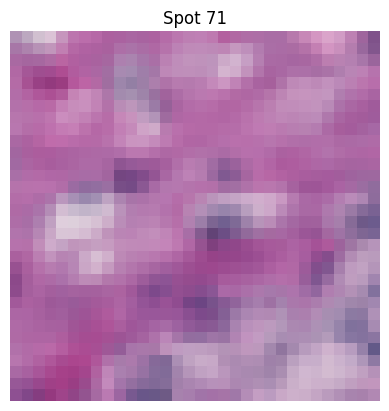

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt

# 加载 npz 文件（记得修改路径）
data = np.load("../npzdata/GSM4565823.npz", allow_pickle=True)

tokens = data["tokens"]             # shape: (N, ), 每个是 list[str]
labels = data["label"]              # shape: (N, 12)
patches = data["patch"]             # shape: (N, H, W, 3) 或 (N, H, W)
spot_names = data.get("spot_names")  # 可选，有的话可以显示名字

# 随机选一个 spot
idx = random.randint(0, len(tokens) - 1)

print(f" Spot index: {idx}")
if spot_names is not None:
    print(f"🧬 Spot name: {spot_names[idx]}")

print("\n Token :")
print(tokens[idx])

print("\n label:")
print(labels[idx])

# 如果有图像 patch
if "patch" in data:
    print(patches[idx].shape)
    patch = np.transpose(patches[idx], (1, 2, 0))
    plt.imshow(patch)
    plt.title(f"Spot {idx}")
    plt.axis("off")
    plt.show()


# 这个是生成词典的

In [ ]:
import json


def build_and_save_tokenizer_dict_json(gene_file_path: str, dict_save_path: str):
    gene_names = set()  # 使用 set 去重
    with open(gene_file_path, "r") as f:
        next(f)  # 跳过表头
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            if len(parts) < 2:
                continue
            gene_name = parts[1].strip().upper()
            if gene_name in ("", "NA"):
                continue
            gene_names.add(gene_name)

    suffixes = ["(H)", "(M)", "(L)"]
    tokens = []
    for gene in gene_names:
        for s in suffixes:
            tokens.append(gene + s)

    # 加入特殊 tokens
    special_tokens = ["[PAD]", "[MASK]", "[UNK]", "[CLS]", "[SEP]"]
    all_tokens = special_tokens + sorted(tokens)  # 排序是为了保证稳定性，可选

    vocab = {token: idx for idx, token in enumerate(all_tokens)}

    with open(dict_save_path, "w", encoding="utf-8") as f_out:
        json.dump(vocab, f_out, indent=2, ensure_ascii=False)

    print(f"✅ 词典已保存，大小: {len(vocab)}，路径: {dict_save_path}")


build_and_save_tokenizer_dict_json(
    "../protein_coding_hg38.txt",
    "../STEncoder/gene_tokenizer_vocab_nolab.json"
)

✅ 词典已保存，大小: 58436，路径: ../STEncoder/gene_tokenizer_vocab.json


In [ ]:
# 这个是没要 H M L 的词典
import json

def build_and_save_tokenizer_dict_json(gene_file_path: str, dict_save_path: str):
    gene_names = set()  # 使用 set 去重
    
    # 读取基因列表（假设第二列是基因名）
    with open(gene_file_path, "r") as f:
        next(f)  # 跳过表头
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            if len(parts) < 2:
                continue
            gene_name = parts[1].strip().upper()
            if gene_name in ("", "NA"):
                continue
            gene_names.add(gene_name)

    # 只用基因名，不加 (H)/(M)/(L)
    tokens = sorted(gene_names)  # 排序保证稳定性

    # 加入特殊 tokens
    special_tokens = ["[PAD]", "[MASK]", "[UNK]", "[CLS]", "[SEP]"]
    all_tokens = special_tokens + tokens

    # 生成词典
    vocab = {token: idx for idx, token in enumerate(all_tokens)}

    # 保存为 JSON
    with open(dict_save_path, "w", encoding="utf-8") as f_out:
        json.dump(vocab, f_out, indent=2, ensure_ascii=False)

    print(f"✅ 词典已保存，大小: {len(vocab)}，路径: {dict_save_path}")


# 运行示例
build_and_save_tokenizer_dict_json(
    "../protein_coding_hg38.txt",
    "../STEncoder/gene_tokenizer_vocab_nolab.json"
)

✅ 词典已保存，大小: 19482，路径: ../STEncoder/gene_tokenizer_vocab_nolab.json
